In [77]:
# 1) importing and loading the data
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# load the 4 working csv files
df_adm = pd.read_csv('ADMISSIONS.csv')
df_cg = pd.read_csv('CAREGIVERS.csv')
df_cpt = pd.read_csv('CPTEVENTS.csv')
df_call = pd.read_csv('CALLOUT.csv')

# parsing timestamps
df_adm['admittime'] = pd.to_datetime(df_adm['admittime'])
time_cols = ['createtime', 'acknowledgetime']
df_call[time_cols] = df_call[time_cols].apply(pd.to_datetime)

# styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (11, 7)

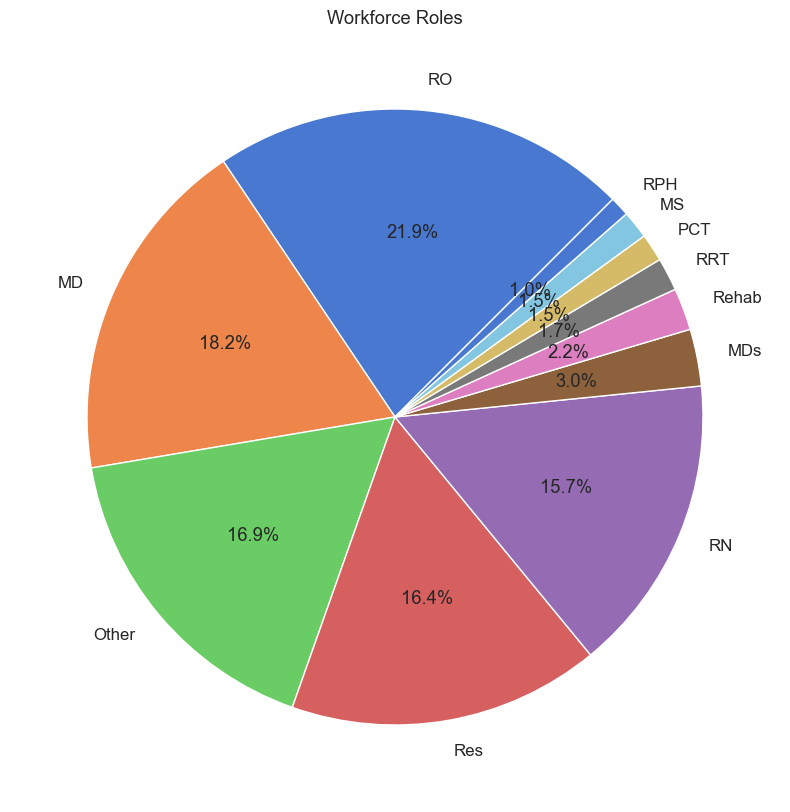

In [78]:
# 2) visual 1: job titles (pie chart)
# top 10 and placing rest in others category
top_jobs = df_cg['label'].value_counts().head(10).index.tolist()
df_cg['job_group'] = [x if x in top_jobs else 'Other' for x in df_cg['label']]

# totals for chart
job_stats = df_cg['job_group'].value_counts()

# pie chart
plt.figure(figsize=(10, 10))
plt.pie(job_stats, labels=job_stats.index, autopct='%1.1f%%', startangle=45, 
        colors=sns.color_palette('muted'))
plt.title('Workforce Roles')
plt.show()

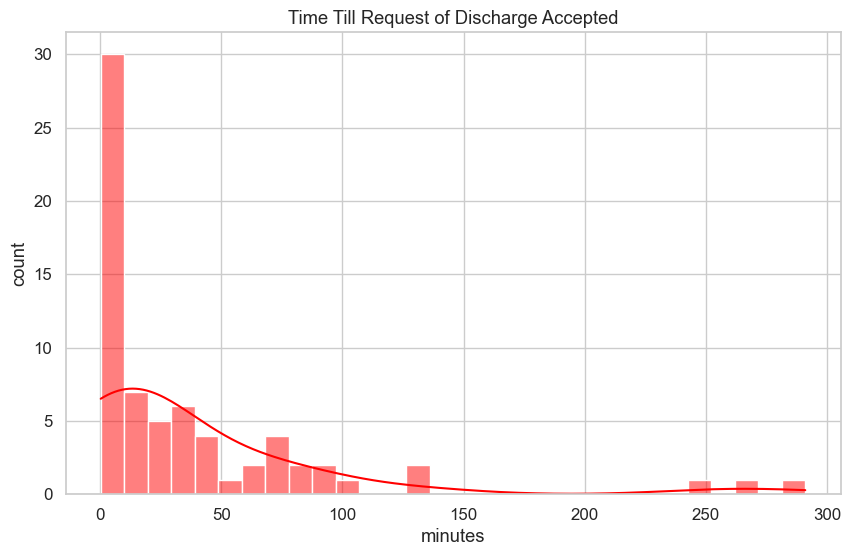

In [79]:
# 3) visual 2: response delay (histogram)
# calculate delay time
df_call['delay'] = (df_call['acknowledgetime'] - df_call['createtime']).dt.total_seconds() / 60

# filtering out outliers (just looking at under 5 hours)
# we don't want negative numbers or extreme delays
df_clean = df_call[(df_call['delay'] > 0) & (df_call['delay'] < 300)]

# plotting
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='delay', bins=30, color='red', kde=True)
plt.title('Time Till Request of Discharge Accepted')
plt.xlabel('minutes')
plt.ylabel('count')
plt.show()

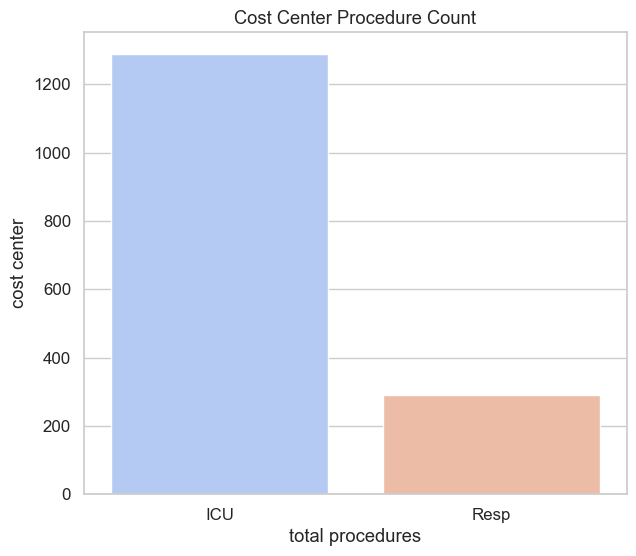

In [80]:
# 4) visual 3: cost centers (bar chart - vertical)
# counting the procedures
dept_activity = df_cpt['costcenter'].value_counts()

# plot
plt.figure(figsize=(7, 6))
sns.barplot(x=dept_activity.index, y=dept_activity.values, hue=dept_activity.index, palette='coolwarm', dodge=False)

plt.title('Cost Center Procedure Count')
plt.ylabel('cost center')
plt.xlabel('total procedures')
plt.legend([],[], frameon=False)
plt.show()

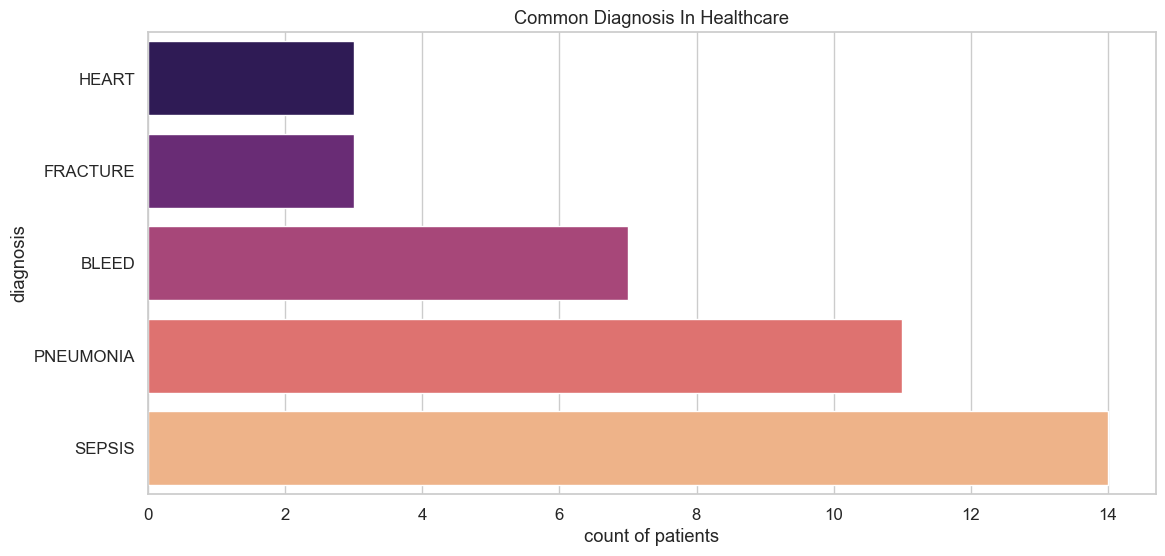

In [81]:
# 5) visual 4: common diagnosis (bar chart - horizontal)
# keywords in data
search_terms = ['SEPSIS', 'HEART', 'PNEUMONIA', 'BLEED', 'FRACTURE']

# get the counts
results = {term: df_adm['diagnosis'].str.contains(term, na=False).sum() for term in search_terms}

# sorting dataframe
final_df = pd.DataFrame(list(results.items()), columns=['disease', 'total']).sort_values('total')

# plot
plt.figure(figsize=(13, 6))
sns.barplot(data=final_df, x='total', y='disease', hue='disease', palette='magma', dodge=False)

plt.title('Common Diagnosis In Healthcare')
plt.xlabel('count of patients')
plt.ylabel('diagnosis')
plt.legend([],[], frameon=False)
plt.show()

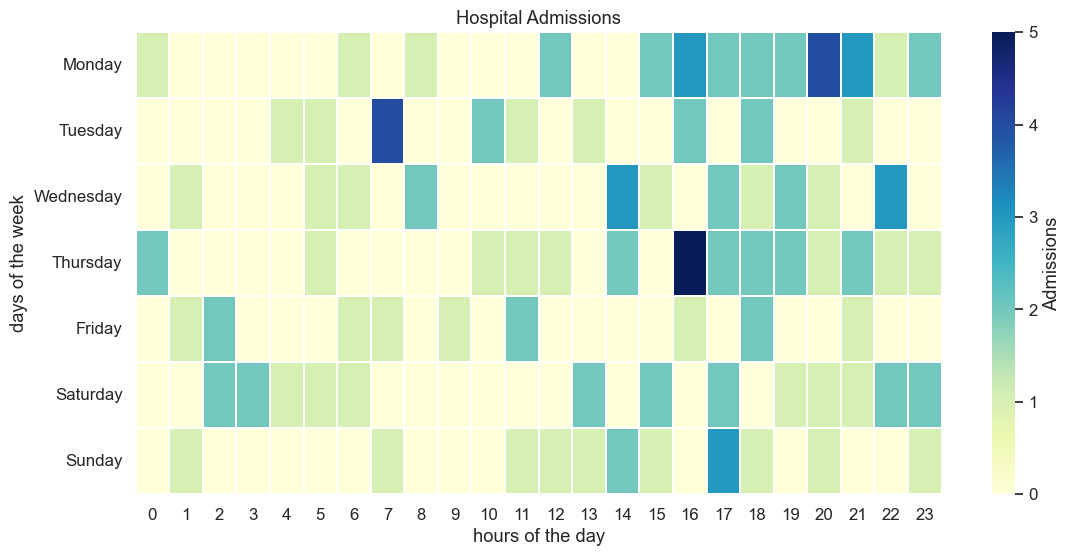

In [82]:
# 6) visual 5: busy times heatmap (novel data visual for bonus credit)
# getting hour/day name from timestamp
df_adm['adm_hour'] = df_adm['admittime'].dt.hour
df_adm['adm_day'] = df_adm['admittime'].dt.day_name()

# create frequency grid
adm_grid = pd.crosstab(df_adm['adm_day'], df_adm['adm_hour'])

# ordering days of week
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
adm_grid = adm_grid.reindex(week_order)

# plot
plt.figure(figsize=(13, 6))
sns.heatmap(adm_grid, cmap='YlGnBu', linewidths=0.3, cbar_kws={'label': 'Admissions'})
plt.title('Hospital Admissions')
plt.xlabel('hours of the day')
plt.ylabel('days of the week')
plt.show()